# Brune Comparison

Compare Sentinel-2 derived trapping efficiencies derived in `../../create_figs.R` with the Brune Curve as in 
> Brune, G. M. (1953). Trap efficiency of reservoirs. Eos, Transactions American Geophysical Union, 34(3), 407-418.

Parameters are also derived from the US Army Corps of Engineers: https://www.hec.usace.army.mil/confluence/hmsdocs/hmstrm/erosion-and-sediment-transport-under-construction/reservoir-sediment-methods/brune-sediment-trap

$$TE=a(1-2e^{-bV_*^{0.35}})$$
where 
- Min: $a=95,\ b=5.37$
- Median: $a=97,\ b=6.42$
- Max: $a=100,\ b=7.71$

$$V_*=\frac{V_{\text{reservoir}}}{V_{\text{inflow}}}=\frac{\text{Volume}}{\text{Annual water inflow}}$$

Dam parameters are from the US Army Corps of Engineers "Pertinent Data" (files in this folder).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import polars as pl

sns.set_palette("dark")

# Create dataframe
df = pd.DataFrame({
    'dam_name': [
        'West Point Dam',
        'Walter F. George Lock and Dam',
        'George W. Andrews Lock and Dam'
    ],
    'lake_name':[
        'West Point Lake',
        'Eufaula',
        'George W. Andrews Lake'
    ],
    'sentinel2_TE_flux': [
        # Flux derived
        72.8,
        61.7,
        13.1
    ],
    'sentinel2_TE_SSC': [
        # SSC derived
        77.4,
        63.6,
        4.2
    ],
    # Volume of the reservoir, convert to Acre ft to m^3
    'volume_m3': [
        # West point doesn't have 'Total Volume at Static Full'
        # so pull data from NID
        605_000 * 1233.48,
        884_572 * 1233.48,
        18_180 * 1233.48
    ],
    # Mean annual flow (cfs to m^3/yr)
    # Average annual flow since dam completed
    'Q_m3yr': [
        4_712 * 0.0283168 * (60 * 60 * 24 * 365.25),
        9_155 * 0.0283168 * (60 * 60 * 24 * 365.25),
        10_767 * 0.0283168 * (60 * 60 * 24 * 365.25) # Didn't have pre/post so take mean annual
    ],
})
df['V_star'] = df['volume_m3'] / df['Q_m3yr']
df.to_csv('../../figure-data/Brune_curve_data.csv')
df

,dam_name,lake_name,sentinel2_TE_flux,sentinel2_TE_SSC,volume_m3,Q_m3yr,V_star
0,West Point Dam,West Point Lake,72.8,77.4,7.462554e+08,4.210691e+09,0.177229
1,Walter F. George Lock and Dam,Eufaula,61.7,63.6,1.091102e+09,8.181002e+09,0.133370
2,George W. Andrews Lock and Dam,George W. Andrews Lake,13.1,4.2,2.242467e+07,9.621502e+09,0.002331


## Now plot

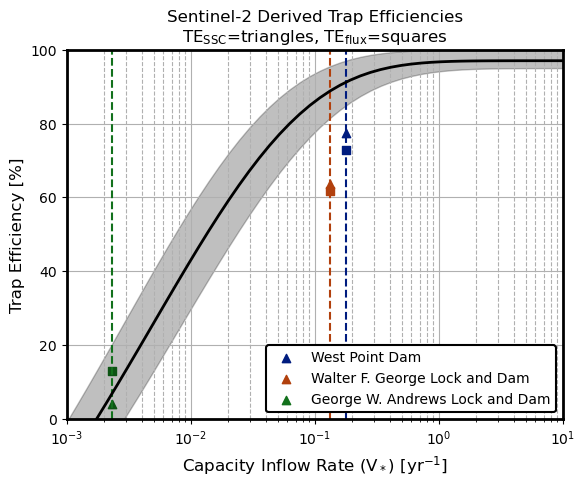

In [5]:
xs = np.logspace(-3, 1)

@np.vectorize
def TE(V_star, a, b):
    "Brune curve"
    return a*(1-2*(np.e**(-b * (V_star**0.35))))

y_min = TE(xs, 95, 5.37)
y_median = TE(xs, 97, 6.42)
y_max = TE(xs, 100, 7.71)


fig, ax = plt.subplots()

# Plot sentinel_2
for row, c in zip(df.itertuples(), sns.color_palette('dark')):
    x = row.V_star
    y_flux = row.sentinel2_TE_flux
    y_ssc = row.sentinel2_TE_SSC
    ax.scatter(x, y_ssc, marker='^', color=c, label=row.dam_name)
    ax.scatter(x, y_flux, marker='s', color=c)
    ax.axvline(x, ls='dashed', c=c)
    

# Plot Brune curves
# ax.plot(
#     xs, y_min, lw=2, color='darkblue', ls='dashed',
#     label='Minimum (a=95, b=5.37)'
# )
ax.plot(
    xs, y_median, lw=2, color='k',
    # label='Median (a=97, b=6.42)'
)
# ax.plot(
#     xs, y_max, lw=2, color='darkred', ls='dashed',
#     label='Maximum (a=100, b=7.71)'
# )
ax.fill_between(
    xs, y_max, y_min, color='k', alpha=0.25
)
ax.set_xlim(xs[0], xs[-1])
ax.set_ylim(0, 100)
ax.set_xscale('log')
leg = ax.legend()

frame = leg.get_frame()
frame.set_facecolor('white')   # white background
frame.set_edgecolor('black')   # black border
frame.set_linewidth(1.5)       # thicker border (optional)
frame.set_alpha(1)             # fully opaque
# Make border bigger
for spine in ax.spines.values():
    spine.set_linewidth(2) 
    
ax.grid(True)
ax.grid(True, which='minor', ls='dashed')
ax.set_xlabel(r'Capacity Inflow Rate (V$_*$) [yr$^{-1}$]', fontsize='large')
ax.set_ylabel(r'Trap Efficiency [%]', fontsize='large')
ax.set_title('Sentinel-2 Derived Trap Efficiencies\n'+r'TE$_{\text{SSC}}$=triangles, TE$_{\text{flux}}$=squares')
plt.savefig('../Brune_curve.png', dpi=300)
plt.show()